### Neurophysiologic signatures of breakpoint

https://rcweb.dartmouth.edu/SunX/ieeg_progressive_ratio_dataset/

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import mne
import re
from scipy.signal import welch
import matplotlib.pyplot as plt

BIDS = Path.home() / "Library/CloudStorage/GoogleDrive-bzheng112@gmail.com/My Drive/data/PR-iEEG/raw/bids"

In [2]:
def subjects():
    return sorted(p.name[4:] for p in BIDS.glob("sub-*"))

def events(sub):
    f = BIDS / f"sub-{sub}/ses-01/ieeg/sub-{sub}_ses-01_task-pr_events.tsv"
    ev = pd.read_csv(f, sep="\t", na_values="n/a",
                     dtype={"trial_number": "Int64", "reward_level": "Int64", "set_index": "Int64"})
    return ev.sort_values("onset", kind="stable").reset_index(drop=True)

### behavior

In [3]:
ev = events("P06")
print(len(ev), ev.trial_type.value_counts().to_dict())
ev.head(6)

896 {'trial_start': 439, 'response': 439, 'reward': 15, 'breakpoint': 3}


,onset,duration,trial_type,value,sample,trial_number,reward_level,effort_coeff,set_index
0,159.386,1.692,trial_start,4,159386,1,50,0.12,1
1,161.078,0.000,response,2,161078,<NA>,<NA>,NaN,<NA>
2,161.134,0.835,trial_start,4,161134,2,50,0.12,1
3,161.968,0.000,response,2,161968,2,50,0.12,1
4,162.630,0.645,trial_start,4,162630,4,50,0.12,1
5,163.274,0.000,response,2,163274,<NA>,<NA>,NaN,<NA>


In [4]:
def trial_counts():
    """Trials per reward level for every subject, counted by trial-number span within each set."""
    out = {}
    for sub in subjects():
        ts = events(sub).query("trial_type == 'trial_start'")
        span = ts.groupby(["reward_level", "set_index"])["trial_number"].agg(lambda t: t.max() - t.min() + 1)
        out[sub] = span.groupby("reward_level").sum()
    return pd.DataFrame(out).T.reindex(columns=[50, 25, 10]).fillna(0).astype(int)

In [5]:
counts = trial_counts()
counts

reward_level,50,25,10
P02SB,88,178,70
P06,194,183,73
P10,767,432,173
P12,42,87,71
P13,358,436,0
P14,861,431,172
P15,871,435,174
P16,864,9,0
P17,1,0,175
P18,357,97,91


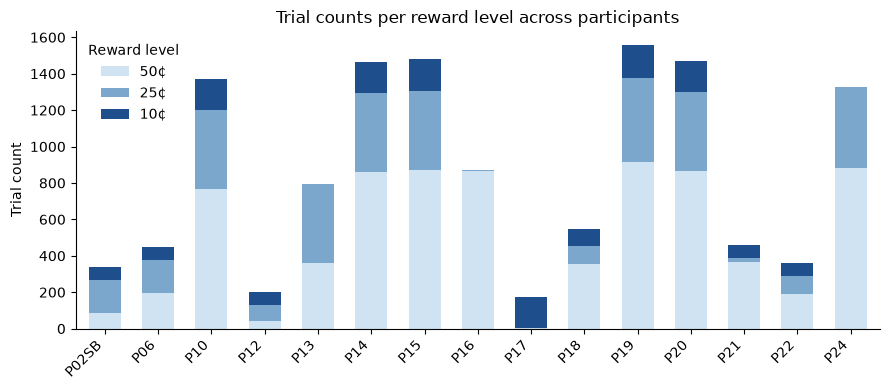

In [6]:
ax = counts.plot.bar(stacked=True, color=["#cfe3f2", "#7ba7cc", "#1f4e8c"], width=0.6, figsize=(9, 4))
ax.set_ylabel("Trial count"); ax.set_xlabel("")
ax.legend(["50¢", "25¢", "10¢"], title="Reward level", frameon=False)
ax.set_title("Trial counts per reward level across participants")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [7]:
def trials():
    """One row per trial across subjects: reward level and response time in ms."""
    rows = []
    for sub in subjects():
        ts = events(sub).query("trial_type == 'trial_start'")
        rows.append(pd.DataFrame({"sub": sub, "reward": ts["reward_level"], "rt_ms": ts["duration"] * 1000}))
    return pd.concat(rows, ignore_index=True)

In [8]:
rt = trials()
rt.groupby(["sub", "reward"])["rt_ms"].median().round().unstack()[[50, 25, 10]]

reward,50,25,10
sub,,,
P02SB,1506.0,1526.0,1370.0
P06,853.0,810.0,836.0
P10,1096.0,1052.0,1073.0
P12,1160.0,1210.0,1151.0
P13,1218.0,1069.0,NaN
P14,1243.0,1186.0,1210.0
P15,951.0,974.0,920.0
P16,889.0,847.0,NaN
P17,1757.0,NaN,1103.0


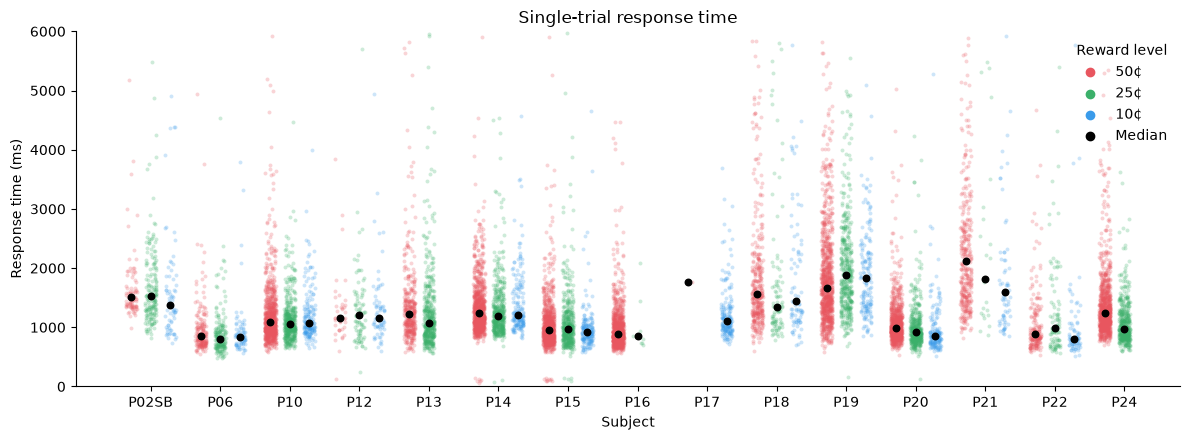

In [9]:
levels, colors, offsets = [50, 25, 10], ["#e8565f", "#3bb06a", "#3a9bea"], [-0.28, 0.0, 0.28]
rng = np.random.default_rng(0)
subs = subjects()

fig, ax = plt.subplots(figsize=(12, 4.5))
for i, sub in enumerate(subs):
    for lev, col, off in zip(levels, colors, offsets):
        y = rt.loc[(rt["sub"] == sub) & (rt["reward"] == lev), "rt_ms"].to_numpy()
        if len(y) == 0:
            continue
        x = i + off + rng.uniform(-0.08, 0.08, len(y))
        ax.scatter(x, y, s=8, color=col, alpha=0.25, linewidths=0)
        ax.scatter(i + off, np.median(y), s=22, color="black", zorder=3)
ax.set_xticks(range(len(subs))); ax.set_xticklabels(subs)
ax.set_ylim(0, 6000); ax.set_ylabel("Response time (ms)"); ax.set_xlabel("Subject")
for lev, col in zip(levels, colors):
    ax.scatter([], [], color=col, label=f"{lev}¢")
ax.scatter([], [], color="black", label="Median")
ax.legend(title="Reward level", frameon=False, loc="upper right")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.set_title("Single-trial response time")
plt.tight_layout()

Slides 13 and 14 not reproducible: the two numbers shown per trial are not in the release.


In [10]:
def sets(sub):
    """One row per set a subject was offered: outcome, trials required and done, intro dwell."""
    ev = events(sub)
    ev["set_of_trial"] = ev["set_index"].where(ev.trial_type == "trial_start").ffill()
    ts = ev[ev.trial_type == "trial_start"].dropna(subset=["set_index"])
    rw = ev[ev.trial_type == "reward"]
    bp = ev[ev.trial_type == "breakpoint"]

    g = ts.groupby("set_index")
    tab = pd.DataFrame({
        "reward":      g["reward_level"].first(),
        "effort":      g["effort_coeff"].first(),
        "first_trial": g["onset"].min(),
        "n_rows":      g.size(),
        "n_trials":    g["trial_number"].max() - g["trial_number"].min() + 1,
    })
    declined = bp[~bp["set_index"].isin(tab.index)].set_index("set_index")
    declined = declined[["reward_level", "effort_coeff"]].rename(columns={"reward_level": "reward", "effort_coeff": "effort"})
    tab = pd.concat([tab, declined]).sort_index()

    tab["required"] = (tab["effort"] * tab["reward"].astype(float)).round().astype(int)
    tab["position"] = (tab.index - 1) % 7 + 1
    tab["rewarded"] = tab.index.isin(rw["set_of_trial"])
    tab["quit"] = tab.index.isin(bp["set_index"])
    tab["outcome"] = np.select([tab["rewarded"], tab["quit"] & tab["n_rows"].isna(), tab["quit"]],
                               ["completed", "declined", "quit_midset"], default="unmarked")
    prev_reward = rw.groupby("set_of_trial")["onset"].last()
    tab["dwell"] = tab["first_trial"] - prev_reward.reindex(tab.index - 1).to_numpy()
    tab.loc[tab["position"] == 1, "dwell"] = np.nan
    tab.insert(0, "sub", sub)
    return tab.rename_axis("set").reset_index()


In [11]:
tab = sets("P13")
tab[["set", "reward", "required", "n_trials", "position", "outcome", "dwell"]]


,set,reward,required,n_trials,position,outcome,dwell
0,1,50,6,6,1,completed,NaN
1,2,50,12,12,2,completed,11.149
2,3,50,26,26,3,completed,2.077
3,4,50,45,46,4,completed,1.697
4,5,50,100,100,5,completed,1.777
5,6,50,167,168,6,completed,32.456
6,7,50,500,<NA>,7,declined,NaN
7,8,25,3,3,1,completed,NaN
8,9,25,6,6,2,completed,2.789
9,10,25,13,13,3,completed,1.207


In [12]:
allsets = pd.concat([sets(s) for s in subjects()], ignore_index=True)
print(len(allsets), allsets.outcome.value_counts().to_dict())
allsets[allsets.outcome != "completed"].groupby(["reward", "outcome"]).size().unstack(fill_value=0)


262 {'completed': 234, 'declined': 16, 'quit_midset': 7, 'unmarked': 5}


outcome,declined,quit_midset,unmarked
reward,,,
10,4,2,1
25,6,2,3
50,6,3,1


https://www.dropbox.com/scl/fi/n73pdlvdae0bx0gbxkzp9/Progressive-ratio-task-LFP-analysis.paper?rlkey=2auguit8jxkneu1abkpripq0u&dl=0

https://rcweb.dartmouth.edu/SunX/ieeg_progressive_ratio_dataset/docs/lfp-analysis.html

### imaging

In [13]:
def roi_of(region):
    """Coarse region of interest from a Destrieux label; 'other' if none of ours."""
    if not isinstance(region, str):
        return "unlocalized"
    if "Amygdala" in region:
        return "amygdala"
    if "Hippocampus" in region:
        return "hippocampus"
    if re.search("G_orbital$|S_orbital-H|S_orbital_med|G_rectus|S_suborbital", region):
        return "OFC"
    if re.search("cingul-Ant|cingul-Mid-Ant", region):
        return "dACC"
    if "White-Matter" in region:
        return "white matter"
    return "other"

In [14]:
EXTRA = r"A1|A2|C3|C4|F3|F4|Ez|PZ|HR|HR_REF|EMG\d|EOG\d|Analogue\d|MICROPHONE|TTLSYNC"
ALIAS = {"RFSG": "RFSGA", "ROF": "ROF-AC", "ROFC": "ROF-AC", "ROPR": "ROPR-AI", "ROAI": "ROPR-AI",
         "LIFG": "LIFG-AC", "RMFG": "RMFG-PSMA", "LFOI": "LFO-I", "RFOI": "RFO-I"}

In [15]:
def channel_table(sub):
    """One row per recorded channel: is it a depth contact, and where is it (strict Destrieux label)."""
    ch = pd.read_csv(BIDS / f"sub-{sub}/ses-01/ieeg/sub-{sub}_ses-01_task-pr_channels.tsv",
                     sep="\t", na_values="n/a", encoding="utf-8-sig")[["name", "type"]]
    ch.insert(0, "sub", sub)
    ch["depth"] = ~ch["name"].str.fullmatch(EXTRA, case=False)
    f = BIDS / f"derivatives/electrodes/sub-{sub}/sub-{sub}_electrodes_full.tsv"
    if not f.exists():
        ch["region"] = np.nan
    else:
        el = pd.read_csv(f, sep="\t", na_values="n/a", encoding="utf-8-sig")
        el = el.set_index(el["name"].str.upper())
        def key(name):
            k = name.upper()
            if k in el.index:
                return k
            stem, num = re.match(r"(.*?)(\d+)$", k).groups() if re.search(r"\d+$", k) else (k, "")
            return ALIAS.get(stem, stem) + num
        ch["key"] = ch["name"].map(key)
        cols = ["region_destrieux", "region_destrieux_rave", "regions_within_2mm", "white_matter",
                "x_mni305_mm", "y_mni305_mm", "z_mni305_mm"]
        ch = ch.join(el[cols].rename(columns={"region_destrieux": "region", "region_destrieux_rave": "region_near",
                                              "regions_within_2mm": "within_2mm", "x_mni305_mm": "x_mni",
                                              "y_mni305_mm": "y_mni", "z_mni305_mm": "z_mni"}), on="key")
        ch = ch.drop(columns="key")
    ch["roi"] = ch["region"].map(roi_of)
    ch.loc[~ch["depth"], "roi"] = "not depth"
    first = ch["name"].str.upper().str[0]
    ch["hemi"] = np.where(ch["depth"], first.where(first.isin(["L", "R"])), None)
    return ch

In [16]:
t = channel_table("P21")
print(len(t), t.depth.sum(), t.region.notna().sum())
t[t.roi == "amygdala"][["name", "region", "region_near", "white_matter", "hemi"]]

100 86 86


,name,region,region_near,white_matter,hemi
13,LA1,Left-Amygdala,ctx_lh_G_oc-temp_med-Parahip,False,L
14,LA2,Left-Amygdala,ctx_lh_G_oc-temp_med-Parahip,False,L
40,RA1,Right-Amygdala,ctx_rh_G_oc-temp_med-Parahip,False,R
41,RA2,Right-Amygdala,Right-Amygdala,False,R
42,RA3,Right-Amygdala,Right-Amygdala,False,R


In [17]:
allch = pd.concat([channel_table(s) for s in subjects()], ignore_index=True)
d = allch[allch.depth]
d.groupby("sub").roi.value_counts().unstack(fill_value=0)[["amygdala", "hippocampus", "OFC", "dACC", "white matter", "other", "unlocalized"]]

roi,amygdala,hippocampus,OFC,dACC,white matter,other,unlocalized
sub,,,,,,,
P02SB,0,0,0,0,0,0,32
P06,0,3,2,0,66,41,0
P10,0,0,0,2,25,46,0
P12,0,0,0,0,0,0,96
P13,0,0,0,0,0,0,128
P14,0,0,0,0,0,0,128
P15,0,6,4,0,47,30,0
P16,2,3,0,3,37,63,0
P17,6,1,2,0,68,30,0


In [18]:
FS = Path.home() / "mne_data/MNE-fsaverage-data/fsaverage/surf"

In [19]:
def pial(hemi, every=4):
    """fsaverage pial surface for one hemisphere: vertices (mm, MNI305) and every k-th triangle."""
    with open(FS / f"{hemi}.pial", "rb") as f:
        f.read(3)                                   # 3-byte magic number
        f.readline(); f.readline()                  # creator line, then a blank line
        n_v, n_f = np.frombuffer(f.read(8), dtype=">i4")
        verts = np.frombuffer(f.read(n_v * 12), dtype=">f4").reshape(n_v, 3)
        faces = np.frombuffer(f.read(n_f * 12), dtype=">i4").reshape(n_f, 3)
    return verts.astype(float), faces[::every]


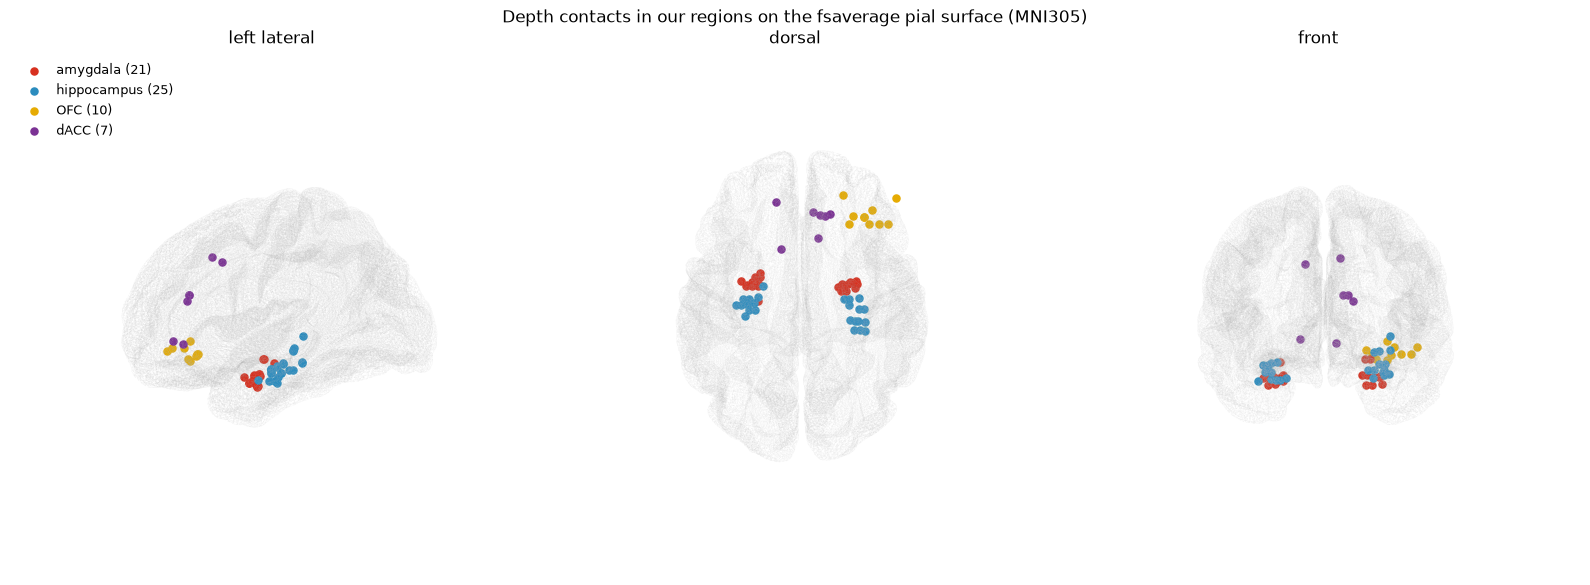

In [20]:
ROI_COLORS = {"amygdala": "#d7301f", "hippocampus": "#2b8cbe", "OFC": "#e6ab02", "dACC": "#7b3294"}
VIEWS = [("left lateral", 0, 180), ("dorsal", 90, -90), ("front", 0, -90)]

loc = allch[allch.depth & allch.x_mni.notna()]
fig, axes = plt.subplots(1, 3, figsize=(16, 6), subplot_kw={"projection": "3d"})
for ax, (title, elev, azim) in zip(axes, VIEWS):
    for hemi in ("lh", "rh"):
        v, f = pial(hemi)
        ax.plot_trisurf(v[:, 0], v[:, 1], v[:, 2], triangles=f, color="#bdbdbd", alpha=0.2, linewidth=0, shade=False)
    for roi, col in ROI_COLORS.items():
        r = loc[loc.roi == roi]
        ax.scatter(r.x_mni, r.y_mni, r.z_mni, s=26, color=col, depthshade=False, label=f"{roi} ({len(r)})")
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((170, 210, 160))
    ax.set_axis_off(); ax.set_title(title)
axes[0].legend(loc="upper left", frameon=False, fontsize=9)
fig.suptitle("Depth contacts in our regions on the fsaverage pial surface (MNI305)", y=0.98)
plt.tight_layout(); plt.subplots_adjust(wspace=0.0)


### SFN abstract